# Bloco 1: SETUP, Bibliotecas e Parâmetros

## Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime
import warnings

# Configurações visuais e bloqueio de avisos poluidoros no console
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Lista de Ativos

In [3]:
# Ações Brasileiras (Infraestrutura, Saneamento, Energia, Bancos, Commodities, etc.)
acoes_br = [
    'SBSP3.SA',  # Sabesp
    'SAPR11.SA', # Sanepar
    'PETR4.SA',  # Petrobras
    'VALE3.SA',  # Vale
    'ITUB4.SA',  # Itaú Unibanco
    'TAEE11.SA', # Taesa
    'WEGE3.SA',  # WEG
    'BBAS3.SA',  # Banco do Brasil
    'B3SA3.SA',  # B3
    'RENT3.SA'   # Localiza
]

# Fundos Imobiliários (FIIs - Papel, Logística, Shoppings)
fiis = [
    'KNCR11.SA', # Kinea Rendimentos (Papel / CDI)
    'HGLG11.SA', # CSHG Logística
    'VISC11.SA', # Vinci Shoppings
    'MXRF11.SA', # Maxi Renda
    'XPLG11.SA', # XP Logística
]

# Renda Fixa Brasileira (Proxies através de ETFs líquidos da B3)
renda_fixa = [
   'B5P211.SA',  # IMA-B 5+ (Inflação Longa)
   'B5MB11.SA',  # IMA-B até 5 anos (Inflação Curta - Proteção de carteira)
   'FIXA11.SA'   # Fundo de Renda Fixa (Mix de pré fixados entre 2,5 e 3 anos)
]

# Ativos Internacionais (Índices que sofrerão ajuste cambial automático)
ativos_internacionais = [
    '^GSPC',  # S&P 500
    '^IXIC',  # NASDAQ Composite
    '^RUT'    # Russell 2000 (Small Caps EUA)
]

# Criptomoedas
cryptos = [
    'BTC-USD', # Bitcoin
    'ETH-USD', # Ethereum
    'SOL-USD'  # Solana
]

# Ticker do Câmbio para a engenharia de conversão
ticker_cambio = 'BRL=X'

# Unificando o universo para facilitar o download massivo no Bloco 2
universo_tickers = acoes_br + fiis + renda_fixa + ativos_internacionais + cryptos + [ticker_cambio]

## Parâmetros do Modelo

In [4]:
# Parâmetros de Risco de Cauda (Proporção Híbrida)
peso_cdar = 0.70
peso_cvar = 0.30

# Definição do Período Histórico Total para Extração
data_inicio = '2020-01-01'
data_fim = '2026-09-01'

# Parâmetros Estruturais do Walk-Forward Analysis (Backtesting)
anos_in_sample = 3         # Janela de Treino (IS): Anos de dados para o Ward calcular a árvore
meses_out_sample = 3       # Janela de Alocação (OOS): Frequência do rebalanceamento de carteira
meses_holdout = 12         # Amostra de Gaveta: Meses isolados e blindados para o teste final
custo_transacao = 0.0020   # 0.20% estimativa de fricção por giro (Corretagem, Slippage, B3)

# Bloco 2: Extração, Limpeza e Engenharia de Dados


Neste bloco, transformamos preços brutos extraídos da internet em uma matriz matemática estável de retornos reais. O mercado financeiro é repleto de sujeira nos dados (feriados não coincidentes, falhas de *feed*, moedas distintas). Se o dado entra sujo, o modelo HERC aprenderá ruído.

**1. O Alinhamento de Feriados (Forward Fill):**
A B3 (Brasil) e a NYSE/NASDAQ (EUA) possuem calendários de feriados diferentes. Para que a Matriz de Distância Euclidiana não colapse com buracos (`NaN`) nesses dias, aplicamos o método `.ffill()`. Ele assume que, se uma bolsa está fechada, o preço do ativo permanece igual ao do último pregão válido.

**2. A Paridade Cambial (O Efeito Dólar):**
Um investidor brasileiro comprando S&P 500 ou Bitcoin está, implicitamente, operando a moeda americana. O retorno de um ativo cotado em Dólar precisa ser unificado geometricamente com a variação do Câmbio (BRL/USD) para representar a verdadeira volatilidade na carteira. A fórmula aplicada é:

$$Retorno_{BRL} = (1 + Retorno_{USD}) \times (1 + Retorno_{BRL/USD}) - 1$$

**3. O "Holdout Set" (A Amostra de Gaveta):**
Este é o escudo anti-overfitting. O código fatiará o histórico de retornos. Os últimos 12 meses serão isolados na variável `dados_holdout` e completamente trancados. Os blocos subsequentes de construção do modelo e *backtest* de janelas rolantes só terão permissão para enxergar a variável `dados_backtest`.

## Extração e Engenharia de Dados

In [5]:
print("Iniciando o download de dados. Isso pode levar alguns segundos...")

Iniciando o download de dados. Isso pode levar alguns segundos...


## Extração e Alinhamento de Calendário

In [6]:
all_data = yf.download(universo_tickers, start=data_inicio, end=data_fim)
precos_brutos_dict = {}

for ticker in universo_tickers:
    if isinstance(all_data.columns, pd.MultiIndex):
        if ('Adj Close', ticker) in all_data.columns:
            precos_brutos_dict[ticker] = all_data['Adj Close'][ticker]
        elif ('Close', ticker) in all_data.columns:
            precos_brutos_dict[ticker] = all_data['Close'][ticker]
    elif ticker in all_data.columns:
        precos_brutos_dict[ticker] = all_data[ticker]

precos_brutos = pd.DataFrame(precos_brutos_dict)

# Remove Sábados (5) e Domingos (6) para alinhar criptos com o mercado tradicional
precos_brutos = precos_brutos[precos_brutos.index.dayofweek < 5]

# Preenche feriados descasados usando ffill
precos_alinhados = precos_brutos.ffill().dropna()

[*********************100%***********************]  25 of 25 completed


## Cálculo de Retornos, Epsilon e Tratamento Cambial

In [7]:
retornos = precos_alinhados.pct_change().dropna()

# Epsilon: Ruído microscópico para evitar colapso de correlação em retornos zerados
np.random.seed(42)
ruido_microscopico = np.random.normal(0, 1e-8, retornos.shape)
retornos = retornos + ruido_microscopico

# Engenharia Cambial
retornos_cambio = retornos[ticker_cambio]
ativos_dolarizados = ativos_internacionais + cryptos

for ativo in ativos_dolarizados:
    if ativo in retornos.columns:
        retornos[ativo] = (1 + retornos[ativo]) * (1 + retornos_cambio) - 1

retornos = retornos.drop(columns=[ticker_cambio])

## Tratando Anomalidades nas Proxies de Renda Fixa (Winsorization)

In [9]:
# É impossível um ETF de Renda Fixa variar 50% em um dia. Cortamos o erro do Yahoo Finance.
# Travamos a oscilação máxima diária em +/- 2.5% para manter a integridade da variância.
limite_rf = 0.025
ativos_rf = ['B5P211.SA', 'B5MB11.SA', 'FIXA11.SA']

for ativo in ativos_rf:
    if ativo in retornos.columns:
        retornos[ativo] = retornos[ativo].clip(lower=-limite_rf, upper=limite_rf)

## Backtest vs Holdout

In [10]:
# Identificando a data final real do dataset baixado
data_final_real = retornos.index[-1]

# Calculando a data de corte (Ex: Hoje menos 12 meses)
data_corte = data_final_real - pd.DateOffset(months=meses_holdout)

# Fatiando os DataFrames
dados_backtest = retornos.loc[:data_corte]
dados_holdout = retornos.loc[data_corte + pd.Timedelta(days=1):]

print("\nExtração e Engenharia concluídas com sucesso!")
print(f"Período de Backtest (IS/OOS): {dados_backtest.index[0].date()} até {dados_backtest.index[-1].date()}")
print(f"Período de Holdout (Gaveta): {dados_holdout.index[0].date()} até {dados_holdout.index[-1].date()}")


Extração e Engenharia concluídas com sucesso!
Período de Backtest (IS/OOS): 2020-11-17 até 2025-08-29
Período de Holdout (Gaveta): 2025-09-01 até 2026-08-31


## Extremos da Série de Backtest

In [11]:
print("\nAmostra dos Retornos Diários Ajustados (Primeiras e Últimas Observações):")

# Criando um DataFrame concatenado com as 5 primeiras e 5 últimas linhas
amostra_visual = pd.concat([dados_backtest.head(5), dados_backtest.tail(5)])

# Formatando a saída para percentual visando a clareza analítica
display(amostra_visual.style.format("{:.2%}").background_gradient(cmap='RdYlGn', axis=None))


Amostra dos Retornos Diários Ajustados (Primeiras e Últimas Observações):


,SBSP3.SA,SAPR11.SA,PETR4.SA,VALE3.SA,ITUB4.SA,TAEE11.SA,WEGE3.SA,BBAS3.SA,B3SA3.SA,RENT3.SA,KNCR11.SA,HGLG11.SA,VISC11.SA,MXRF11.SA,XPLG11.SA,B5P211.SA,B5MB11.SA,FIXA11.SA,^GSPC,^IXIC,^RUT,BTC-USD,ETH-USD,SOL-USD
Date,,,,,,,,,,,,,,,,,,,,,,,,
2020-11-17 00:00:00,-0.31%,1.29%,1.72%,3.16%,0.07%,0.22%,0.13%,1.47%,0.28%,-1.23%,-0.70%,0.14%,-0.18%,0.29%,0.02%,0.27%,-0.36%,0.23%,-1.25%,-0.98%,-0.41%,4.74%,3.63%,-3.11%
2020-11-18 00:00:00,0.67%,0.48%,-0.59%,-0.78%,-2.44%,1.15%,-0.73%,0.23%,0.93%,-2.29%,-0.46%,0.40%,-0.30%,0.09%,0.20%,-0.02%,0.05%,-0.30%,-2.76%,-2.43%,-2.86%,-0.74%,-1.80%,-5.51%
2020-11-19 00:00:00,-1.20%,-1.79%,1.15%,1.91%,0.14%,1.48%,-0.20%,0.99%,2.35%,1.54%,-1.96%,-0.33%,-1.46%,-0.09%,0.33%,0.02%,-0.09%,0.00%,1.04%,1.53%,1.49%,0.72%,-1.00%,-1.17%
2020-11-20 00:00:00,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-1.74%,-1.48%,-1.00%,3.40%,6.93%,-0.18%
2020-11-23 00:00:00,-1.42%,0.53%,5.37%,5.27%,0.31%,-1.91%,-2.99%,-0.29%,-2.22%,-0.18%,0.93%,-0.69%,1.10%,-0.28%,0.39%,-0.15%,-0.55%,-0.61%,1.96%,1.61%,3.26%,-0.01%,21.02%,10.14%
2025-08-25 00:00:00,0.38%,-0.62%,0.59%,0.24%,-0.51%,0.41%,0.61%,-2.20%,-0.08%,-0.00%,0.09%,0.00%,0.01%,-0.21%,-0.19%,0.00%,-0.00%,-0.00%,-1.22%,-1.01%,-1.75%,-6.53%,-10.21%,-7.41%
2025-08-26 00:00:00,-1.96%,-0.50%,-0.72%,0.89%,-0.67%,0.86%,-0.37%,1.65%,-0.88%,-0.58%,0.75%,0.32%,0.12%,0.63%,0.92%,0.00%,-0.00%,0.00%,0.20%,0.23%,0.61%,1.31%,4.98%,4.38%
2025-08-27 00:00:00,2.61%,0.68%,0.76%,-0.05%,1.68%,0.73%,0.40%,1.23%,1.85%,1.69%,0.55%,0.20%,-0.29%,-0.21%,0.18%,-0.00%,0.00%,-0.00%,0.64%,0.61%,1.04%,-0.12%,-1.72%,3.99%
2025-08-28 00:00:00,0.87%,1.21%,0.88%,0.04%,2.08%,0.84%,0.21%,2.04%,2.84%,1.97%,-0.08%,0.34%,0.32%,0.00%,-0.53%,-0.00%,-0.00%,0.00%,0.07%,0.28%,-0.05%,0.94%,-0.16%,5.40%


# Bloco 3: A Geometria do Risco (Matriz de Distância Euclidiana)



Nesta etapa, o modelo abandona a Teoria Moderna do Portfólio clássica e entra no campo da topologia de redes e *Machine Learning*.

### 1. A Matemática da Distância
Se dois ativos possuem correlação perfeita (1), a distância geométrica entre eles deve ser zero (eles ocupam o mesmo lugar no espaço do risco). Se possuem correlação perfeitamente inversa (-1), a distância entre eles é máxima (1).

A transformação obedece à seguinte fórmula:
$$D_{i,j} = \sqrt{0.5 \cdot (1 - \rho_{i,j})}$$

O *Heatmap* (Mapa de Calor) gerado abaixo serve como prova visual. Se a matriz exibir um ruído aleatório (como a estática de uma TV analógica), o mercado está caótico. Se exibir "blocos" de cores sólidas, o modelo já está começando a enxergar os Fatores de Risco Macroeconômicos se formando.

## Cálculo da Correlação e da Distância

In [12]:
print("Calculando a matriz de correlação e convertendo para Distância Euclidiana...")

# Identificar colunas com desvio padrão zero (retornos constantes)
# Essas colunas causam NaNs na matriz de correlação, o que por sua vez causa problemas em `squareform`.
std_devs = dados_backtest.std()
constant_cols = std_devs[std_devs == 0].index.tolist()

if constant_cols:
    print(f"Aviso: Os seguintes ativos possuem retornos constantes (std dev zero) no período de backtest e serão removidos para o cálculo da correlação e distância: {constant_cols}")
    dados_backtest_filtered = dados_backtest.drop(columns=constant_cols)
else:
    dados_backtest_filtered = dados_backtest.copy()

# 1. Calcula a matriz de Correlação de Pearson usando apenas os dados In-Sample / Backtest filtrados
matriz_correlacao = dados_backtest_filtered.corr()

# 2. Converte a Correlação em Distância (Métrica Euclidiana Topológica)
# Arredondamos levemente para evitar erros de ponto flutuação do Python
matriz_correlacao_arredondada = matriz_correlacao.round(10)

# Garantir que não há NaNs remanescentes na matriz de correlação (ex: se algum ativo ainda tiver problema de dados)
# Se houver NaNs após a remoção de colunas constantes, é mais seguro remover esses ativos.
matriz_correlacao_arredondada = matriz_correlacao_arredondada.dropna(axis=0).dropna(axis=1)

# Ensure the DataFrame is not empty after dropping NaNs
if matriz_correlacao_arredondada.empty:
    raise ValueError("A matriz de correlação está vazia após a remoção de ativos com NaNs. Não é possível prosseguir.")

matriz_distancia = np.sqrt(0.5 * (1 - matriz_correlacao_arredondada))

# 3. Preenche a diagonal principal com 0 absoluto (a distância de um ativo para ele mesmo é 0)
np.fill_diagonal(matriz_distancia.values, 0)

# Exibindo os valores da matriz de distância para auditoria (5 primeiras linhas e colunas)
print("\nMatriz de Distância (Amostra 5x5):")
display(matriz_distancia.iloc[:5, :5].style.background_gradient(cmap='Blues_r', axis=None))

Calculando a matriz de correlação e convertendo para Distância Euclidiana...

Matriz de Distância (Amostra 5x5):


,SBSP3.SA,SAPR11.SA,PETR4.SA,VALE3.SA,ITUB4.SA
SBSP3.SA,0.000000,0.508387,0.622487,0.669936,0.566298
SAPR11.SA,0.508387,0.000000,0.646682,0.708252,0.614581
PETR4.SA,0.622487,0.646682,0.000000,0.608289,0.569964
VALE3.SA,0.669936,0.708252,0.608289,0.000000,0.625067
ITUB4.SA,0.566298,0.614581,0.569964,0.625067,0.000000


## Heatmap de Correlação e Distância


Gerando o Heatmap da Matriz de Distância...


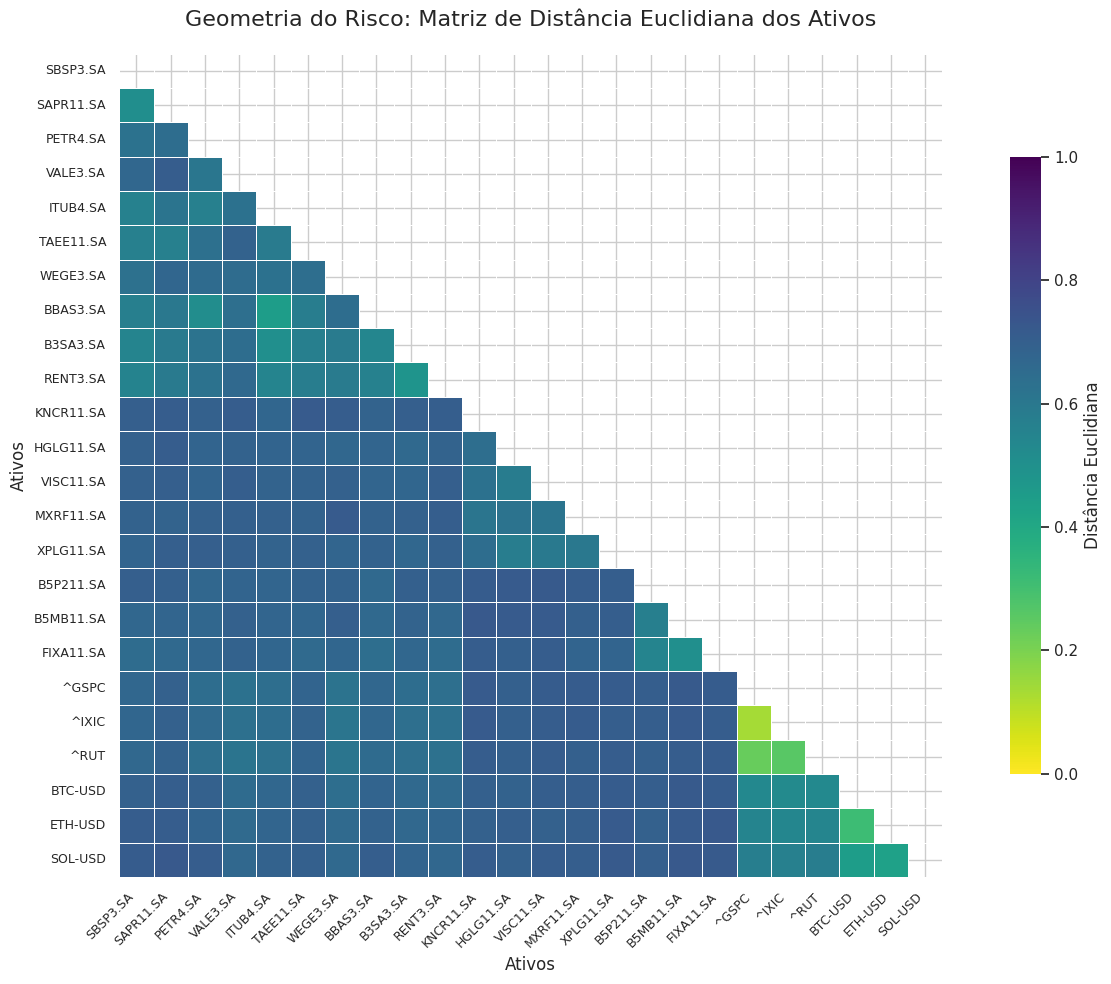

In [13]:
print("\nGerando o Heatmap da Matriz de Distância...")

# Configurando o tamanho da figura geométrica
plt.figure(figsize=(14, 10))

# Criando uma máscara para esconder a metade superior do gráfico (já que a matriz é simétrica)
mask = np.triu(np.ones_like(matriz_distancia, dtype=bool))

# Plotando o Heatmap usando Seaborn
sns.heatmap(matriz_distancia,
            mask=mask,
            cmap='viridis_r', # Paleta invertida: Cores quentes = Menor distância (Maior similaridade)
            vmax=1.0,
            vmin=0.0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .75, "label": "Distância Euclidiana"},
            annot=False) # Mantido False para não poluir visualmente com dezenas de números

plt.title('Geometria do Risco: Matriz de Distância Euclidiana dos Ativos', fontsize=16, pad=20)
plt.xlabel('Ativos', fontsize=12)
plt.ylabel('Ativos', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Exibe o gráfico na tela
plt.show()

# Bloco 4: Topologia e Hierarquia (O Método de Ward)



 Nesta etapa, o modelo HERC realiza o agrupamento aglomerativo (*Agglomerative Hierarchical Clustering*) para estruturar a topologia do mercado, transformando os pontos soltos da matriz de distância em uma árvore conectada (Dendrograma).

### 1. A Evolução: Ward vs. Single Linkage
O modelo HRP original utiliza o algoritmo *Single Linkage*, que calcula a distância entre os clusters focando apenas no vizinho mais próximo. Essa abordagem é altamente suscetível ao efeito *chaining* (encadeamento), onde um *outlier* cria clusters assimétricos em formato de "corrente", unindo ativos que não compartilham o mesmo fator de risco estrutural.

O HERC resolve essa falha utilizando o **Método de Ward**. Em vez de medir distâncias espaciais simples, o Método de Ward fundamenta-se na Análise de Variância (ANOVA). O algoritmo funde dois clusters apenas se essa união resultar no menor aumento possível da Variância Interna Total do novo grupo formado.

### 2. A Intuição Matemática (Minimização do ESS)
O motor do Método de Ward é a Soma dos Quadrados dos Erros (ESS). Para um grupo $k$ com média $\mu_k$, o ESS mede a coesão do cluster:
$$ESS_k = \sum_{i=1}^{n_k} (x_i - \mu_k)^2$$

A cada iteração, o algoritmo avalia todas as fusões possíveis e escolhe aquela que minimiza o $\Delta ESS$. O resultado é a formação de clusters esféricos e densos, que traduzem com alta fidelidade os Fatores de Risco da economia real (como blocos puros de *Utilities*, Instituições Financeiras ou *Commodities*).

### 3. A Matriz de Ligação (Linkage Matrix) e o Dendrograma
O algoritmo do SciPy retornará um registro matemático de cada "casamento" entre os ativos, gerando a *Linkage Matrix*. O Dendrograma gerado a seguir ilustra a hierarquia completa e como a divisão top-down operará no próximo passo. O eixo Y (*Height*) representa a distância ou o "custo" de variância exigido para realizar a união.

## Condensação da Matriz de Distância

In [15]:
print("Condensando a Matriz Euclidiana e preparando o motor de agrupamento...")

# A função linkage do SciPy exige uma matriz de distância 1D (condensada)
# Extraímos os valores da matriz de distância calculada no Bloco 3
dist_array = matriz_distancia.values

# Para evitar erros de formatação no SciPy, garantimos que a matriz é estritamente simétrica
# e com zeros absolutos na diagonal principal
dist_array = (dist_array + dist_array.T) / 2
np.fill_diagonal(dist_array, 0)

# Transforma a matriz quadrada (NxN) em um vetor linear contendo apenas as distâncias únicas
distancia_condensada = squareform(dist_array)

Condensando a Matriz Euclidiana e preparando o motor de agrupamento...


## Aplicação do Método de Ward (clustering)

In [16]:
print("Executando o Método de Ward (Minimização de Variância Interna)...")

# O SciPy constrói a Linkage Matrix (N-1 linhas por 4 colunas) registrando cada fusão topológica
matriz_ligacao_ward = sch.linkage(distancia_condensada, method='ward')

# Opcional: Criar um DataFrame para auditar a Linkage Matrix (Casamento 1, Casamento 2, Distância, Qtd de Ativos)
df_linkage = pd.DataFrame(matriz_ligacao_ward,
                          columns=['Cluster_A', 'Cluster_B', 'Distancia_Ward', 'Qtd_Ativos_Originais'])

Executando o Método de Ward (Minimização de Variância Interna)...


## Dendograma


Desenhando o Dendrograma do Portfólio...



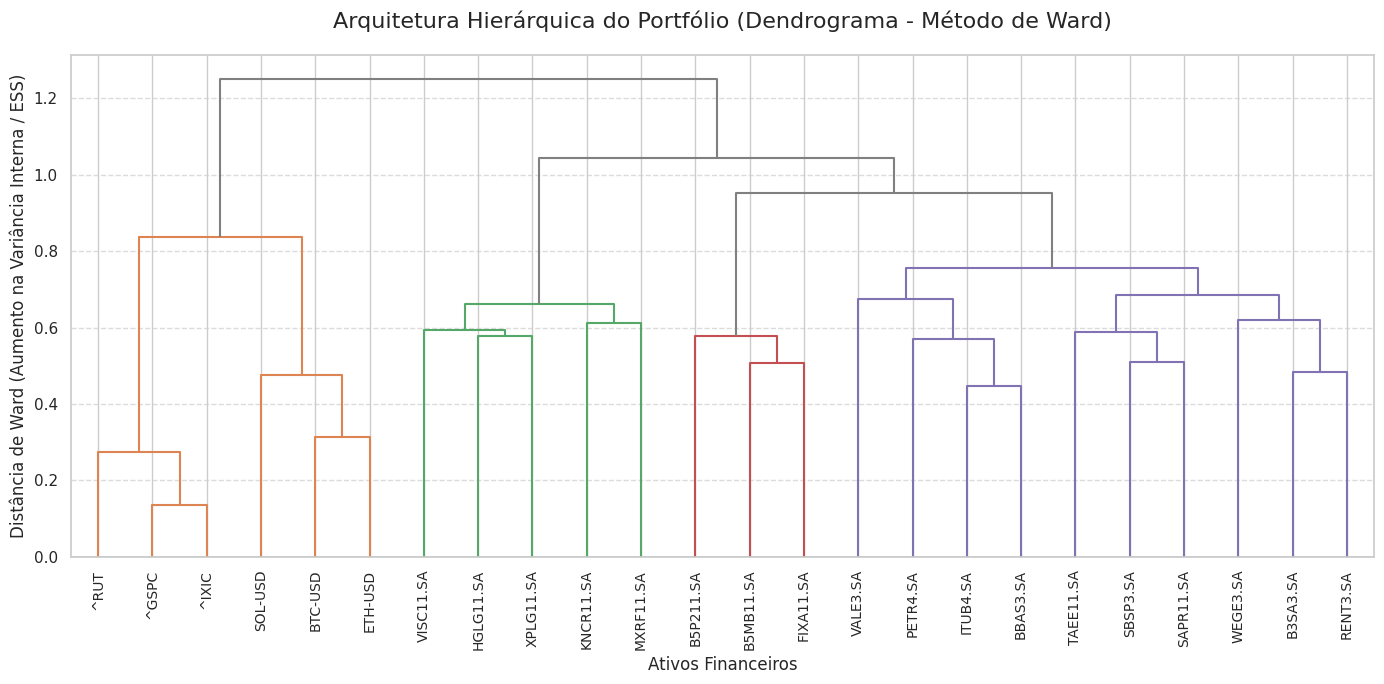

In [17]:
print("\nDesenhando o Dendrograma do Portfólio...\n")

# Configuração estética do gráfico para um layout de nível institucional
plt.figure(figsize=(14, 7))
plt.title('Arquitetura Hierárquica do Portfólio (Dendrograma - Método de Ward)', fontsize=16, pad=20)
plt.xlabel('Ativos Financeiros', fontsize=12)
plt.ylabel('Distância de Ward (Aumento na Variância Interna / ESS)', fontsize=12)

# Construção da árvore
dendrograma = sch.dendrogram(matriz_ligacao_ward,
                             labels=matriz_distancia.columns,
                             leaf_rotation=90,          # Rotaciona os tickers para 90 graus para facilitar a leitura
                             leaf_font_size=10,
                             color_threshold=None,      # Permite que o SciPy defina as cores baseadas nas fusões macro
                             above_threshold_color='grey') # A cor do galho principal (a raiz do mercado)

# Refinando o visual
plt.axhline(y=0, c='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe a topologia na tela
plt.show()

# Bloco 5: Alocação de Capital HERC (Bisseção Recursiva Top-down)



Esta é a etapa onde o capital é efetivamente distribuído pela árvore. O modelo HERC difere dos otimizadores tradicionais porque não busca a "Variância Mínima", mas sim a Paridade de Risco focada em momentos extremos de crise.

### 1. As Métricas de Risco de Cauda
Substituímos o risco clássico por um motor híbrido:
*   **CVaR (Conditional Value at Risk):** Analisa apenas os 5% piores dias de retorno histórico. Responde à pergunta: *"Quando o mercado entra em pânico diário, qual é a média do meu prejuízo?"*
*   **CDaR (Conditional Drawdown at Risk):** Analisa as 5% piores quedas contínuas (do topo histórico ao fundo). Responde à pergunta: *"Quanto tempo e quão fundo meu patrimônio afunda durante uma longa recessão?"*
Nós fundimos essas métricas na proporção definida no Bloco 1 (ex: 70% CDaR / 30% CVaR).

### 2. A Bisseção Recursiva (Top-Down)
O algoritmo lê o Dendrograma de cima para baixo. Em cada bifurcação, ele distribui o capital (que começa em 100%) em proporção inversa ao risco do galho.
$$Peso_{Esquerdo} = \frac{Risco_{Direito}}{Risco_{Esquerdo} + Risco_{Direito}}$$

### 3. Naive Risk Parity (Folhas da Árvore)
Quando o algoritmo chega no último nível (os ativos individuais dentro de um micro-cluster), ele entende que aqueles ativos são altamente correlacionados. Portanto, ele divide o capital restante entre eles de forma ingênua (inversamente proporcional ao risco individual), blindando a carteira sem precisar inverter a matriz.

## Função de Risco Extremo (CVaR e CDaR)

In [18]:
def calcular_cvar(retornos, alpha=0.05):
    """Calcula o Conditional Value at Risk (Média dos piores 5% retornos)"""
    if len(retornos) == 0: return 0.0
    retornos_ordenados = np.sort(retornos)
    indice_corte = int(alpha * len(retornos_ordenados))
    # Se o índice for 0, pega o pior retorno absoluto para evitar erro
    if indice_corte == 0: return abs(retornos_ordenados[0])
    piores_retornos = retornos_ordenados[:indice_corte]
    return abs(np.mean(piores_retornos))

def calcular_cdar(retornos, alpha=0.05):
    """Calcula o Conditional Drawdown at Risk (Média dos piores 5% Drawdowns)"""
    if len(retornos) == 0: return 0.0
    curva_capital = (1 + retornos).cumprod()
    picos_historicos = curva_capital.cummax()
    drawdowns = (curva_capital - picos_historicos) / picos_historicos

    drawdowns_ordenados = np.sort(drawdowns.dropna()) # Ordena do mais negativo pro menor
    indice_corte = int(alpha * len(drawdowns_ordenados))
    if indice_corte == 0: return abs(drawdowns_ordenados[0])
    piores_drawdowns = drawdowns_ordenados[:indice_corte]
    return abs(np.mean(piores_drawdowns))

def calcular_risco_hibrido(retornos):
    """Funde o CDaR e CVaR com base nos pesos definidos no Bloco 1"""
    cvar = calcular_cvar(retornos)
    cdar = calcular_cdar(retornos)
    return (peso_cdar * cdar) + (peso_cvar * cvar)

## Algoritimo HERC (Travessia da Árvore e Naive Risk Parity)

In [19]:
print("Iniciando a Bisseção Recursiva baseada em Risco de Cauda...")

ativos_lista = matriz_distancia.columns.tolist()

# Passo A: Calcular o risco individual de todos os ativos (Usado no Naive Risk Parity)
risco_individual = {ativo: calcular_risco_hibrido(dados_backtest[ativo]) for ativo in ativos_lista}
risco_inverso = {ativo: 1.0 / risco_individual[ativo] for ativo in ativos_lista}

def calcular_retorno_cluster(node):
    """Calcula o retorno agregado de um galho aplicando Naive Risk Parity aos seus membros"""
    if node.is_leaf():
        return dados_backtest[ativos_lista[node.id]]

    folhas_idx = node.pre_order()
    ativos_no_cluster = [ativos_lista[i] for i in folhas_idx]

    soma_risco_inverso = sum([risco_inverso[a] for a in ativos_no_cluster])

    # O retorno do cluster é a soma ponderada dos retornos dos ativos que o compõem
    retorno_agregado = sum([(risco_inverso[a] / soma_risco_inverso) * dados_backtest[a] for a in ativos_no_cluster])
    return retorno_agregado

def alocacao_bissecao_herc(node, peso_recebido, pesos_finais):
    """Navega a árvore Top-Down dividindo o capital"""
    # Se chegou na folha (ativo único), ele recebe a fatia exata de capital que desceu pelo galho
    if node.is_leaf():
        pesos_finais[ativos_lista[node.id]] = peso_recebido
        return

    filho_esquerdo = node.get_left()
    filho_direito = node.get_right()

    # Mede o retorno da sub-árvore inteira
    ret_esq = calcular_retorno_cluster(filho_esquerdo)
    ret_dir = calcular_retorno_cluster(filho_direito)

    # Calcula o risco de cauda do bloco inteiro
    risco_esq = calcular_risco_hibrido(ret_esq)
    risco_dir = calcular_risco_hibrido(ret_dir)

    # Equal Risk Contribution (Proporção Inversa)
    # Proteção matemática caso o risco dê zero
    soma_riscos = risco_esq + risco_dir
    if soma_riscos == 0:
        fator_esq = 0.5
    else:
        fator_esq = risco_dir / soma_riscos

    fator_dir = 1.0 - fator_esq

    # Desce na árvore distribuindo o capital atual multiplicado pela nova proporção
    alocacao_bissecao_herc(filho_esquerdo, peso_recebido * fator_esq, pesos_finais)
    alocacao_bissecao_herc(filho_direito, peso_recebido * fator_dir, pesos_finais)

Iniciando a Bisseção Recursiva baseada em Risco de Cauda...


## Execução e Cálculo dos Pesos Finais

In [20]:
# Converte a matriz de ligação em um objeto Tree para ser navegado
arvore_hierarquica = sch.to_tree(matriz_ligacao_ward)

# Dicionário que guardará o peso de cada ativo (começa vazio)
pesos_carteira = {}

# Dispara a bisseção começando da Raiz (100% de capital ou 1.0)
alocacao_bissecao_herc(arvore_hierarquica, 1.0, pesos_carteira)

# Converte para DataFrame e ordena do maior peso para o menor
df_pesos = pd.DataFrame(list(pesos_carteira.items()), columns=['Ativo', 'Peso (%)'])
df_pesos['Peso (%)'] = df_pesos['Peso (%)'] * 100
df_pesos = df_pesos.sort_values(by='Peso (%)', ascending=False).reset_index(drop=True)

print("\nPesos Alocados pelo Modelo HERC:")
display(df_pesos.style.format({'Peso (%)': "{:.2f}%"}).background_gradient(cmap='Greens', axis=None))


Pesos Alocados pelo Modelo HERC:


,Ativo,Peso (%)
0,B5P211.SA,43.81%
1,KNCR11.SA,19.88%
2,MXRF11.SA,7.77%
3,VISC11.SA,4.29%
4,HGLG11.SA,3.90%
5,B5MB11.SA,3.02%
6,FIXA11.SA,2.85%
7,^RUT,2.11%
8,TAEE11.SA,1.78%
9,XPLG11.SA,1.70%


## Gráfico de Rosca

In [21]:
# Cria um gráfico interativo com Plotly para mostrar a distribuição do capital
fig = px.pie(df_pesos,
             values='Peso (%)',
             names='Ativo',
             hole=0.4,
             title='Distribuição de Capital (HERC - Risco Híbrido)',
             color_discrete_sequence=px.colors.qualitative.Prism)

fig.update_traces(textposition='inside', textinfo='percent+label',
                  hovertemplate='Ativo: %{label}<br>Alocação: %{value:.2f}%')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

# Bloco 6: Cálculo e Visualização da Contribuição de Risco Marginal



Neste bloco, nós desmascaramos a ilusão da alocação de capital e revelamos a verdadeira essência da Paridade de Risco (Risk Parity). O objetivo do HERC não é dividir o *dinheiro* em fatias iguais, mas sim dividir o *risco* de forma equilibrada através da hierarquia da árvore.

### 1. Capital vs. Risco
1% alocado em um ativo extremamente volátil (como Criptomoedas ou Ações de alto beta) pode causar o mesmo estrago financeiro na carteira do que 40% alocados em um título de Renda Fixa de baixa volatilidade.

Para provar que o portfólio está verdadeiramente diversificado e protegido contra choques, precisamos medir a **Contribuição de Risco Marginal** de cada ativo.

### 2. A Intuição Matemática
Em modelos de risco de cauda baseados na topologia, a contribuição de risco isolada de um ativo $i$ na carteira pode ser aproximada multiplicando-se o peso financeiro que ele recebeu ($w_i$) pelo seu risco de cauda individual original ($Risco\_Hibrido_i$).
$$RC_i = w_i \times Risco\_Hibrido_i$$

Para entendermos a proporção exata dentro do portfólio, nós normalizamos esse valor para que a soma de todos os riscos seja igual a 100%:
$$RC_i (\%) = \frac{RC_i}{\sum_{j=1}^{N} RC_j} \times 100$$



In [22]:
print("Calculando a Contribuição de Risco de cada ativo na carteira...")

Calculando a Contribuição de Risco de cada ativo na carteira...


## Cálculo da Contribuição de Risco

In [23]:
# Recuperamos o peso fracionário (de 0 a 1) do DataFrame gerado no Bloco 5
df_risco = df_pesos.copy()
df_risco['Peso Fracionario'] = df_risco['Peso (%)'] / 100.0

# Mapeamos o risco individual híbrido calculado no Bloco 5 para cada ativo
df_risco['Risco Individual'] = df_risco['Ativo'].map(risco_individual)

# Multiplicamos o Peso pelo Risco Individual para obter a Contribuição Absoluta
df_risco['Contribuicao Absoluta'] = df_risco['Peso Fracionario'] * df_risco['Risco Individual']

# Normalizamos para descobrir qual a porcentagem de risco que cada ativo traz para o bolo total
soma_risco_total = df_risco['Contribuicao Absoluta'].sum()
df_risco['Contribuicao Risco (%)'] = (df_risco['Contribuicao Absoluta'] / soma_risco_total) * 100

# Ordenamos do maior contribuidor de risco para o menor
df_risco = df_risco.sort_values(by='Contribuicao Risco (%)', ascending=True).reset_index(drop=True)

## Visualização em Tabela

In [24]:
print("\nAuditoria: Comparação entre Peso de Capital e Contribuição de Risco")
colunas_exibicao = ['Ativo', 'Peso (%)', 'Contribuicao Risco (%)']
display(df_risco[colunas_exibicao].sort_values(by='Contribuicao Risco (%)', ascending=False)
        .style.format({'Peso (%)': "{:.2f}%", 'Contribuicao Risco (%)': "{:.2f}%"})
        .background_gradient(cmap='Oranges', subset=['Contribuicao Risco (%)'])
        .background_gradient(cmap='Greens', subset=['Peso (%)']))


Auditoria: Comparação entre Peso de Capital e Contribuição de Risco


,Ativo,Peso (%),Contribuicao Risco (%)
23,MXRF11.SA,7.77%,10.88%
22,KNCR11.SA,19.88%,10.88%
21,VISC11.SA,4.29%,8.20%
20,^RUT,2.11%,7.84%
19,SOL-USD,0.77%,7.50%
18,B5P211.SA,43.81%,5.25%
17,HGLG11.SA,3.90%,4.62%
16,XPLG11.SA,1.70%,4.62%
15,VALE3.SA,1.11%,4.03%
14,^GSPC,1.36%,3.94%


# Bloco 7: Walk-forward Analysis, Custos e Performance Out-of-sample

Na academia, modelos matemáticos costumam falhar miseravelmente quando colocados no mundo real porque sofrem de *Overfitting* (superajuste ao passado). O otimizador de Markowitz clássico decora o gabarito do *In-Sample*, mas entra em colapso no *Out-of-Sample*.

Para provar que o HERC sobrevive à incerteza, nós vamos construir uma máquina do tempo: o **Walk-Forward Analysis (Janelas Rolantes)**.

### 1. A Engenharia da Janela Deslizante
O modelo não fará uma única fotografia da matriz de distância. Ele entrará em um *loop* contínuo:
1. Pega os últimos **3 anos** de pregões.
2. Reconstrói a árvore de Ward e a Bisseção Recursiva de cauda.
3. Aloca o capital para os próximos **3 meses** (no escuro, sem saber o futuro).
4. Desliza a janela 3 meses para a frente e repete a operação.

### 2. O Ralo Financeiro (Turnover e Custos de Transação)
Toda vez que a janela rolar e o modelo rebalancear a carteira, os pesos mudarão. A diferença entre o "Peso Antigo" e o "Peso Novo" gera o **Turnover (Giro de Carteira)**.
Na vida real, girar a carteira custa dinheiro (corretagem, emolumentos da B3, impostos e o *slippage* no *bid/ask*). Nós cobraremos um pedágio de **0.20%** sobre cada giro. Se o modelo for instável, os custos destruirão a curva de capital.

### 3. As Métricas de Elite (Raffinot)
Avaliaremos o resultado real (*Out-of-Sample* descontado dos custos) usando o arsenal estatístico proposto por Thomas Raffinot:

*   **ASR (Adjusted Sharpe Ratio):** Um Sharpe penalizado por retornos assimétricos e caudas gordas.
*   **CEQ (Certainty-Equivalent Return):** A taxa livre de risco que empataria com a satisfação (utilidade) teórica desse portfólio.
*   **MDD (Max Drawdown):** A pior queda sofrida pelo modelo operando na vida real.
*   **SSPW:** Métrica de diversificação (quanto mais próximo de 0, menos concentrada é a carteira).
*   **TO (Turnover Médio):** A média de capital girado a cada rebalanceamento.

##

In [25]:
import scipy.stats as stats

print("Iniciando simulação de Janelas Rolantes (Walk-Forward). Isso pode demorar...")

Iniciando simulação de Janelas Rolantes (Walk-Forward). Isso pode demorar...


## Encapsulamento do Motor HERC para Rodar no Loop

In [26]:
def obter_pesos_herc_dinamico(df_janela):
    """Encapsula as lógicas dos Blocos 3, 4 e 5 para rodar isoladamente a cada trimestre."""

    # 1. Limpeza de volatilidade zero (Proteção)
    std_devs = df_janela.std()
    ativos_validos = std_devs[std_devs > 0].index.tolist()
    df_limpo = df_janela[ativos_validos]

    # 2. Correlação e Distância (Bloco 3)
    corr = df_limpo.corr().dropna(axis=0, how='all').dropna(axis=1, how='all')
    dist = np.sqrt(0.5 * (1 - corr.round(10)))
    np.fill_diagonal(dist.values, 0)

    # 3. Ward e Árvore (Bloco 4)
    dist_condensada = squareform((dist.values + dist.values.T) / 2)
    linkage = sch.linkage(dist_condensada, method='ward')
    arvore = sch.to_tree(linkage)
    lista_ativos = dist.columns.tolist()

    # 4. Cálculo de Risco Individual
    r_individual = {ativo: calcular_risco_hibrido(df_limpo[ativo]) for ativo in lista_ativos}
    r_inverso = {ativo: 1.0 / r_individual[ativo] if r_individual[ativo] > 0 else 0 for ativo in lista_ativos}

    # 5. Bisseção Recursiva Top-Down (Bloco 5)
    def ret_cluster(node):
        if node.is_leaf(): return df_limpo[lista_ativos[node.id]]
        ativos_cluster = [lista_ativos[i] for i in node.pre_order()]
        soma_inv = sum([r_inverso[a] for a in ativos_cluster])
        if soma_inv == 0: return df_limpo[ativos_cluster].mean(axis=1) # Fallback
        return sum([(r_inverso[a] / soma_inv) * df_limpo[a] for a in ativos_cluster])

    pesos = {}
    def alocar(node, peso_recebido):
        if node.is_leaf():
            pesos[lista_ativos[node.id]] = peso_recebido
            return
        esq = node.get_left()
        _dir = node.get_right()
        risco_esq = calcular_risco_hibrido(ret_cluster(esq))
        risco_dir = calcular_risco_hibrido(ret_cluster(_dir))

        soma_risco = risco_esq + risco_dir
        fator_esq = risco_dir / soma_risco if soma_risco > 0 else 0.5
        alocar(esq, peso_recebido * fator_esq)
        alocar(_dir, peso_recebido * (1 - fator_esq))

    alocar(arvore, 1.0)

    # Reintegrando ativos congelados com peso zero (para manter simetria do DataFrame)
    pesos_finais = pd.Series(pesos)
    ativos_faltantes = [a for a in df_janela.columns if a not in pesos_finais.index]
    if ativos_faltantes:
        pesos_finais = pd.concat([pesos_finais, pd.Series(0, index=ativos_faltantes)])

    return pesos_finais.reindex(df_janela.columns).fillna(0)

## O Loop do Tempo (Walk-Forward) e Custos de Transação

In [27]:
curva_capital_oos = []
pesos_anteriores = None
historico_turnover = []
historico_sspw = []

# Datas de controle do laço
data_inicio_is = dados_backtest.index[0]
data_fim_is = data_inicio_is + pd.DateOffset(years=anos_in_sample)

# Variável de progresso
ciclo = 1

while data_fim_is < dados_backtest.index[-1]:
    data_fim_oos = data_fim_is + pd.DateOffset(months=meses_out_sample)
    if data_fim_oos > dados_backtest.index[-1]:
        data_fim_oos = dados_backtest.index[-1]

    df_in_sample = dados_backtest.loc[data_inicio_is:data_fim_is]
    df_out_sample = dados_backtest.loc[data_fim_is + pd.Timedelta(days=1):data_fim_oos]

    if df_out_sample.empty: break

    # 1. O Modelo aprende o passado (IS) e gera alocação
    novos_pesos = obter_pesos_herc_dinamico(df_in_sample)

    # 2. Medindo a Fricção (Turnover e Custos)
    if pesos_anteriores is None:
        turnover = 0.0 # Sem giro no dia 1, é a montagem da carteira inicial
    else:
        turnover = np.abs(novos_pesos - pesos_anteriores).sum()

    historico_turnover.append(turnover)
    historico_sspw.append((novos_pesos**2).sum())

    # 3. Aplicando os pesos no futuro cego (OOS)
    retornos_portfolio = (df_out_sample * novos_pesos).sum(axis=1)

    # Subtrai o custo de transação do primeiro dia do novo trimestre
    retornos_portfolio.iloc[0] -= (turnover * custo_transacao)

    curva_capital_oos.append(retornos_portfolio)

    # 4. Desliza a Janela
    data_inicio_is += pd.DateOffset(months=meses_out_sample)
    data_fim_is += pd.DateOffset(months=meses_out_sample)
    pesos_anteriores = novos_pesos
    ciclo += 1

# Unificando a curva de capital OOS real
retornos_finais_oos = pd.concat(curva_capital_oos)

print(f"Simulação concluída! Total de {ciclo-1} rebalanceamentos trimestrais executados.")

Simulação concluída! Total de 8 rebalanceamentos trimestrais executados.


## Métricas Institucionais de Raffinot

In [28]:
print("\nCalculando Métricas de Performance...")

# Fatores de anualização
dias_uteis = 252
mu_diario = retornos_finais_oos.mean()
sigma_diario = retornos_finais_oos.std()
mu_anual = mu_diario * dias_uteis
sigma_anual = sigma_diario * np.sqrt(dias_uteis)

# 1. Índice Sharpe Tradicional
sharpe_ratio = mu_anual / sigma_anual

# 2. Adjusted Sharpe Ratio (ASR) - Penaliza Assimetria e Caudas Gordas
skewness = stats.skew(retornos_finais_oos)
# Usamos kurtosis(fisher=False) para obter a Curtose de Pearson (onde a normal = 3)
kurt = stats.kurtosis(retornos_finais_oos, fisher=False)

ASR = sharpe_ratio * (1 + (skewness / 6) * sharpe_ratio - ((kurt - 3) / 24) * (sharpe_ratio**2))

# 3. Certainty-Equivalent Return (CEQ) - Assumindo Risk-Free de 0% e Aversão 1
CEQ = mu_anual - (0.5 * (sigma_anual**2))

# 4. Maximum Drawdown (MDD)
cota_capital = (1 + retornos_finais_oos).cumprod()
pico_historico = cota_capital.cummax()
drawdowns = (cota_capital - pico_historico) / pico_historico
MDD = abs(drawdowns.min())

# 5. Médias Estruturais (SSPW e Turnover)
SSPW = np.mean(historico_sspw)
TO = np.mean(historico_turnover)

# Montando a Tabela de Resultados
df_metricas = pd.DataFrame({
    'Métrica': ['ASR (Adjusted Sharpe)', 'CEQ (Certainty-Equivalent)', 'MDD (Max Drawdown)', 'TO (Turnover Médio)', 'SSPW (Concentração)'],
    'Resultado': [f"{ASR:.3f}", f"{CEQ*100:.2f}%", f"{MDD*100:.2f}%", f"{TO*100:.2f}%", f"{SSPW:.3f}"]
})

display(df_metricas.style.hide(axis="index").set_properties(**{'background-color': '#f4f4f9', 'color': 'black', 'border-color': 'white'}))


Calculando Métricas de Performance...


Métrica,Resultado
ASR (Adjusted Sharpe),1.044
CEQ (Certainty-Equivalent),4.07%
MDD (Max Drawdown),0.93%
TO (Turnover Médio),34.52%
SSPW (Concentração),0.363


## Curva de Capital

In [29]:
fig_equity = go.Figure()
fig_equity.add_trace(go.Scatter(x=cota_capital.index, y=cota_capital.values,
                                mode='lines', name='HERC Portfólio (OOS)',
                                line=dict(color='DarkGreen', width=2.5)))

fig_equity.update_layout(title='Evolução Patrimonial OOS (Walk-Forward com Custos de Transação)',
                         xaxis_title='Data', yaxis_title='Multiplicador de Capital (Cota Inicial = 1.0)',
                         height=500, title_x=0.5, template='plotly_white')
fig_equity.show()

# Bloco 8: Holdout Set

O *Holdout Set* é o Santo Graal da modelagem preditiva e de alocação. Durante toda a simulação do Bloco 7, o modelo jamais enxergou os dados do último ano (Setembro de 2025 a Setembro de 2026). Essa janela ficou trancada em uma variável isolada.

### A Lógica do Teste Cego
1. **O Treinamento Final:** Nós vamos entregar ao HERC todo o histórico de dados do *backtest* (de Jan/2020 a Ago/2025) de uma só vez. Ele usará essa base massiva para calcular a "Árvore Mestra" e a alocação de risco definitiva.

2. **A Execução:** Pegaremos esses pesos finais e os aplicaremos diretamente na gaveta (*Holdout*), simulando o que aconteceria se você tivesse montado essa carteira no final de 2025 e a deixado rodar no piloto automático durante todo o ano de 2026.

Se o modelo sobreviver a essa janela cega com um bom *Sharpe Ajustado* (ASR) e um *Max Drawdown* controlado, a sua arquitetura HERC está cientificamente comprovada e pronta para gerir capital real.

In [30]:
print("Abrindo a Gaveta (Holdout Set) e processando o último ano de mercado...")

Abrindo a Gaveta (Holdout Set) e processando o último ano de mercado...


## Treinamento Final e Alocação

In [31]:
# O modelo estuda TUDO o que aconteceu no passado (Jan 2020 a Ago 2025)
pesos_definitivos = obter_pesos_herc_dinamico(dados_backtest)

print("\nPesos Definitivos alocados para o ano do Holdout:")
df_pesos_holdout = pd.DataFrame({'Ativo': pesos_definitivos.index, 'Peso (%)': pesos_definitivos.values * 100})
df_pesos_holdout = df_pesos_holdout[df_pesos_holdout['Peso (%)'] > 0].sort_values(by='Peso (%)', ascending=False)
display(df_pesos_holdout.style.format({'Peso (%)': "{:.2f}%"}).background_gradient(cmap='Blues', axis=None))


Pesos Definitivos alocados para o ano do Holdout:


,Ativo,Peso (%)
15,B5P211.SA,43.81%
10,KNCR11.SA,19.88%
13,MXRF11.SA,7.77%
12,VISC11.SA,4.29%
11,HGLG11.SA,3.90%
16,B5MB11.SA,3.02%
17,FIXA11.SA,2.85%
20,^RUT,2.11%
5,TAEE11.SA,1.78%
14,XPLG11.SA,1.70%


## Aplicação no Futuro Cego (OOS Puro)

In [32]:
# Multiplica os retornos do último ano desconhecido pelos pesos definidos
retornos_holdout = (dados_holdout * pesos_definitivos).sum(axis=1)

# Cobra o custo de transação da montagem dessa carteira (giro em relação à última do Bloco 7)
turnover_holdout = np.abs(pesos_definitivos - pesos_anteriores).sum()
retornos_holdout.iloc[0] -= (turnover_holdout * custo_transacao)

## Métricas do Holdout e Auditoria de Risco

In [33]:
print("\nMétricas de Performance do Ano Cego (2025-2026):")

# Anualização
mu_holdout = retornos_holdout.mean() * 252
sigma_holdout = retornos_holdout.std() * np.sqrt(252)

# Sharpe e ASR
sharpe_holdout = mu_holdout / sigma_holdout
skew_holdout = stats.skew(retornos_holdout)
kurt_holdout = stats.kurtosis(retornos_holdout, fisher=False)
ASR_holdout = sharpe_holdout * (1 + (skew_holdout / 6) * sharpe_holdout - ((kurt_holdout - 3) / 24) * (sharpe_holdout**2))

# Drawdown
cota_holdout = (1 + retornos_holdout).cumprod()
pico_holdout = cota_holdout.cummax()
drawdowns_h = (cota_holdout - pico_holdout) / pico_holdout
MDD_holdout = abs(drawdowns_h.min())

df_metricas_holdout = pd.DataFrame({
    'Métrica': ['ASR (Sharpe Ajustado)', 'Retorno Anualizado', 'Volatilidade Anual', 'MDD (Max Drawdown)'],
    'Resultado': [f"{ASR_holdout:.3f}", f"{mu_holdout*100:.2f}%", f"{sigma_holdout*100:.2f}%", f"{MDD_holdout*100:.2f}%"]
})
display(df_metricas_holdout.style.hide(axis="index").set_properties(**{'background-color': '#eef2f5', 'color': 'black', 'border-color': 'white'}))


Métricas de Performance do Ano Cego (2025-2026):


Métrica,Resultado
ASR (Sharpe Ajustado),-0.286
Retorno Anualizado,10.90%
Volatilidade Anual,4.15%
MDD (Max Drawdown),1.85%


## Visualiazação do Holdout

In [34]:
fig_holdout = go.Figure()
fig_holdout.add_trace(go.Scatter(x=cota_holdout.index, y=cota_holdout.values,
                                 mode='lines', name='HERC (Holdout Cego)',
                                 line=dict(color='DarkBlue', width=3)))

fig_holdout.update_layout(title='Evolução Patrimonial no Holdout Set (Set/2025 a Set/2026)',
                          xaxis_title='Data', yaxis_title='Multiplicador de Capital (Cota Inicial = 1.0)',
                          height=500, title_x=0.5, template='plotly_white')
fig_holdout.show()

## Identificação de Anomalias (Caso Ocorram)

In [35]:
print("Investigando anomalias no Holdout (Maiores altas diárias irreais):")
maiores_altas = dados_holdout.max() * 100
df_investigacao = maiores_altas.sort_values(ascending=False).to_frame(name='Maior Retorno Diário (%)')
display(df_investigacao.head(5).style.background_gradient(cmap='Reds'))

Investigando anomalias no Holdout (Maiores altas diárias irreais):


,Maior Retorno Diário (%)
ETH-USD,17.746534
SOL-USD,13.438286
BTC-USD,13.222953
WEGE3.SA,10.054156
RENT3.SA,8.863685
